In [1]:
from simfile import SimFile
from simulation import Simulation
from validation import switchOffAllEffects
import os
import math
import numpy as np
import matplotlib.pyplot as plt

In [2]:
sim = Simulation("Blooming")
switchOffAllEffects(sim)
sim.outputDir = os.environ["PLATO_WORKDIR"]

# One full-column exposure

sim["ObservingParameters/NumExposures"] = 1
sim["SubField/NumRows"] = 4510
sim["SubField/NumColumns"] = 1

# Make sure no sources are located in the sub-field

sim["ObservingParameters/DecPointing"] = -sim["ObservingParameters/DecPointing"]

# Enable CTI

sim["PSF/Model"] = "MappedFromFileSymmetrical"

In [3]:
starCatalogFilename = os.environ["PLATO_WORKDIR"] + "generatedFromPixelCoordinates.starcat"
sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename

In [4]:
output = sim.createStarCatalogFileFromPixelCoordinates(np.array([2255 + 0.5]), np.array([0.5]), np.array([7.5]), np.array([1]), starCatalogFilename)
output = sim.run(removeOutputFile = True)
columnWithoutBlooming = output.getImage(0)

In [5]:
sim["CCD/IncludeFullWellSaturation"] = "yes"
output = sim.run(removeOutputFile = True)
columnWithBlooming = output.getImage(0)


saturationLimit = sim["CCD/FullWellSaturation"]

36600250.0
36600250.0


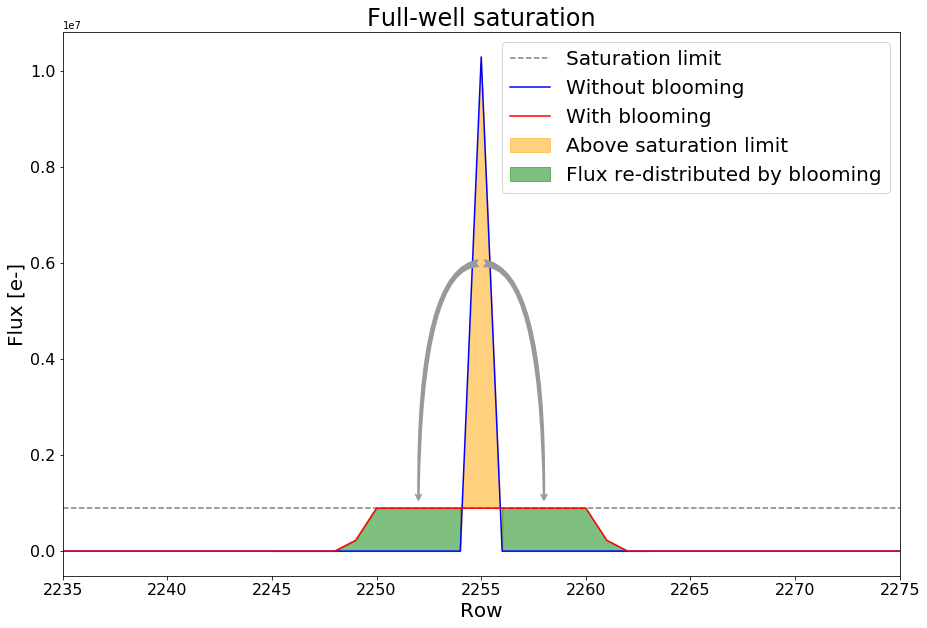

In [6]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



plt.axhline(y = saturationLimit, color = "0.5", linestyle = "dashed", label = "Saturation limit")

###############
# From PlatoSim
###############

plt.plot(columnWithoutBlooming, "b", label="Without blooming")
plt.plot(columnWithBlooming, "r", label="With blooming")

ax.fill_between(np.arange(2254, 2257), np.ravel(columnWithBlooming)[2254:2257], np.ravel(columnWithoutBlooming)[2254:2257], color="orange", alpha=0.5, label="Above saturation limit")
ax.fill_between(np.arange(2245, 2255), np.ravel(columnWithoutBlooming)[2245:2255], np.ravel(columnWithBlooming)[2245:2255], color="g", alpha=0.5, label="Flux re-distributed by blooming")
ax.fill_between(np.arange(2256, 2264), np.ravel(columnWithoutBlooming)[2256:2264], np.ravel(columnWithBlooming)[2256:2264], color="g", alpha=0.5)


########
# Layout
########

plt.title("Full-well saturation", fontsize = 24)
plt.xlabel("Row", fontsize = 20)
plt.ylabel("Flux [e-]", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

plt.xlim([2255 - 20, 2255 + 20])


plt.annotate(s='', xy=(2258, 0.1e7), xytext=(2255, 0.6e7), arrowprops=dict(arrowstyle='fancy', fc="0.6", ec="none", connectionstyle="angle3,angleA=0,angleB=-90"), fontsize=20)
plt.annotate(s='', xy=(2252, 0.1e7), xytext=(2255, 0.6e7), arrowprops=dict(arrowstyle='fancy', fc="0.6", ec="none", connectionstyle="angle3,angleA=0,angleB=-90"), fontsize=20)

print(np.sum(columnWithoutBlooming))
print(np.sum(columnWithBlooming))